
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_03_intuicion_estadistica_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Intuición estadística

## Model Selection and Train/Validation/Test Sets
[1] Reference http://cs229.stanford.edu/syllabus.html

Just because a learning algorithm fits a training set well, that does not mean it is a good hypothesis. It could over fit and as a result your predictions on the test set would be poor. The error of your hypothesis as measured on the data set with which you trained the parameters will be lower than the error on any other data set.
Given many models with different complexities (for example polynomial degree), we can use a systematic approach to identify the 'best' function. In order to choose the model of your hypothesis, you can test each degree of polynomial and look at the error result.

One way to break down our dataset into the three sets is:
Training set: 60%
Cross validation set: 20%
Test set: 20%

We can now calculate three separate error values for the three different sets using the following method:
1. Optimize the parameters in Θ using the training set for each polynomial degree.
2. Find the polynomial degree d with the least error using the cross validation set.
3. Estimate the generalization error using the test set with J_{test}

This way, the degree of the polynomial d has not been trained using the test set.



## Para entregar


1. Para los modelos generados en la sesión 3 tomar el 20% como datos para realizar el test y el 80% para realizar el entrenamiento y la validacion cruzada (por ejemplo 70% entrenamiento y 10% validacion cruzada). Construir una curva del score en función del parámetro gamma del clasificador que se esta empleando. ¿Cual presenta una mejor solución al problema?.

2. Construir las curvas de aprendizaje estadístico para el modelo descrito, comprobar que la solución es similar a la que se obtiene a través de sklearn. GridSearch: https://scikit-learn.org/stable/modules/grid_search.html

3. Tomando el mejor modelo para los datos ahora van crear nuevos datasets donde el modelo se espera no va a ser optimo sino que presenta overfitting y underfitting. Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar graficamente un ejemplo de overfitting y uno de underfitting con el modelo óptimo anterior. Analizar los resultados.


## Solución propuesta (puntos 1, 2 y 3)

En las siguientes celdas se resuelven todos los puntos solicitados.

Estrategia general:

1. Crear un dataset sintético de clasificación binaria en 2D para poder visualizar fronteras.
2. Dividir en `train/validation/test` con proporciones 70% / 10% / 20%.
3. Evaluar `SVC` variando `gamma` y seleccionar el mejor según validación.
4. Construir curvas de aprendizaje y comparar contra `GridSearchCV`.
5. Generar dos nuevos datasets para ilustrar un caso de sobreajuste y otro de subajuste.

### Configuración inicial

Primero importamos librerías y definimos funciones auxiliares para:
- generar datasets gaussianos en 2D,
- graficar fronteras de decisión,
- calcular y visualizar curvas de aprendizaje.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score


def make_gaussian_data(n0, n1, mu0, mu1, cov0, cov1, seed=42):
    rng = np.random.default_rng(seed)
    X0 = rng.multivariate_normal(mean=mu0, cov=cov0, size=n0)
    X1 = rng.multivariate_normal(mean=mu1, cov=cov1, size=n1)
    y0 = np.zeros(n0, dtype=int)
    y1 = np.ones(n1, dtype=int)

    X = np.vstack([X0, X1])
    y = np.hstack([y0, y1])
    return X, y


def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, zz, alpha=0.25, levels=[-0.5, 0.5, 1.5], cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k", cmap="coolwarm", alpha=0.85)
    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid(alpha=0.2)
    plt.show()


def plot_learning(estimator, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 6),
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Train")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.plot(train_sizes, val_mean, marker="s", label="Validación")
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
    plt.title(title)
    plt.xlabel("Número de muestras de entrenamiento")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    return train_sizes, train_mean, val_mean

### Punto 1: split 70/10/20 y curva de score vs gamma

Proceso:

1. Construimos un dataset base en 2D con dos clases gaussianas.
2. Hacemos split estratificado: 20% test y 80% para train+validación.
3. Del 80% restante tomamos 10% del total para validación (equivale a 12.5% de ese bloque), quedando 70% train.
4. Entrenamos `SVC(kernel='rbf')` para una grilla de valores de `gamma` y graficamos `accuracy` en train/validación.
5. Seleccionamos el `gamma` con mayor score de validación y evaluamos en test.

Tamaños:
Train: 630 | Val: 90 | Test: 180


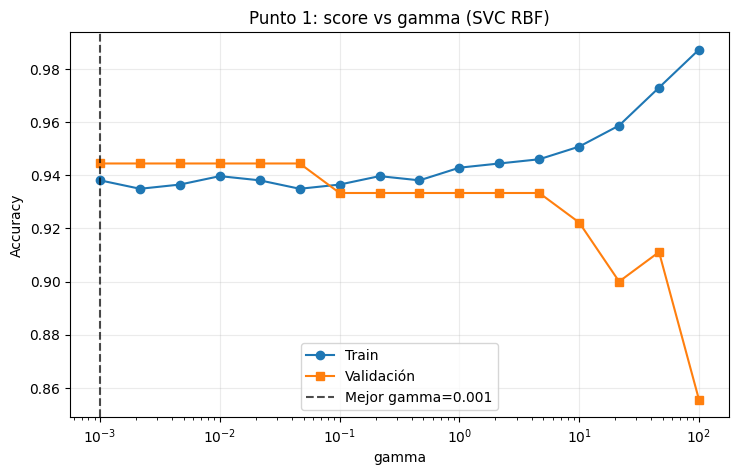

Mejor gamma por validación: 0.001000
Score de test con mejor gamma: 0.9333


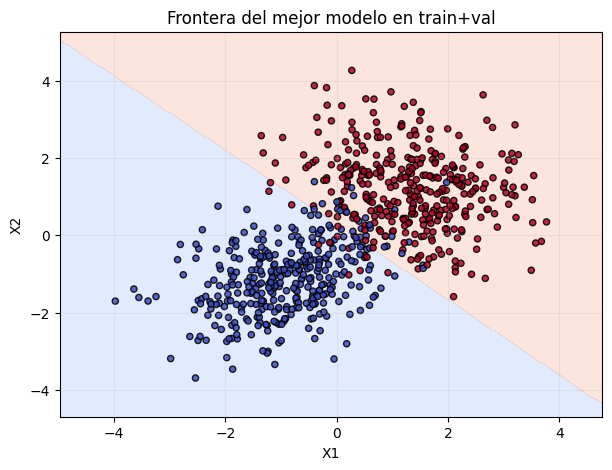

In [2]:
# Dataset base
mu0 = [-1.0, -1.0]
mu1 = [1.4, 1.2]
cov0 = [[1.0, 0.35], [0.35, 1.0]]
cov1 = [[1.0, -0.25], [-0.25, 1.0]]

X, y = make_gaussian_data(
    n0=450,
    n1=450,
    mu0=mu0,
    mu1=mu1,
    cov0=cov0,
    cov1=cov1,
    seed=7,
)

# 20% test, 80% train+val
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=7,
    stratify=y,
)

# De 80% -> 70% train y 10% val (val_size relativo = 0.125)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.125,
    random_state=7,
    stratify=y_trainval,
)

print("Tamaños:")
print("Train:", X_train.shape[0], "| Val:", X_val.shape[0], "| Test:", X_test.shape[0])

# Barrido de gamma
gamma_grid = np.logspace(-3, 2, 16)
train_scores = []
val_scores = []

for g in gamma_grid:
    clf = SVC(kernel="rbf", gamma=g, C=1.0, random_state=7)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    val_scores.append(accuracy_score(y_val, clf.predict(X_val)))

best_idx = int(np.argmax(val_scores))
best_gamma = float(gamma_grid[best_idx])

best_clf = SVC(kernel="rbf", gamma=best_gamma, C=1.0, random_state=7)
best_clf.fit(X_train, y_train)
test_score = accuracy_score(y_test, best_clf.predict(X_test))

# Curva score vs gamma
plt.figure(figsize=(8.5, 5))
plt.semilogx(gamma_grid, train_scores, marker="o", label="Train")
plt.semilogx(gamma_grid, val_scores, marker="s", label="Validación")
plt.axvline(best_gamma, color="k", linestyle="--", alpha=0.7, label=f"Mejor gamma={best_gamma:.4g}")
plt.title("Punto 1: score vs gamma (SVC RBF)")
plt.xlabel("gamma")
plt.ylabel("Accuracy")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"Mejor gamma por validación: {best_gamma:.6f}")
print(f"Score de test con mejor gamma: {test_score:.4f}")

plot_decision_boundary(best_clf, X_trainval, y_trainval, "Frontera del mejor modelo en train+val")

### Punto 2: curvas de aprendizaje y comparación con GridSearchCV

Proceso:

1. Con el mejor `gamma` del punto 1, trazamos la curva de aprendizaje para diagnosticar sesgo/varianza.
2. En paralelo ejecutamos `GridSearchCV` sobre `C` y `gamma` para validar que la selección manual por curva es consistente.
3. Comparamos el mejor resultado de GridSearch con el obtenido en el punto 1 sobre el conjunto de test.

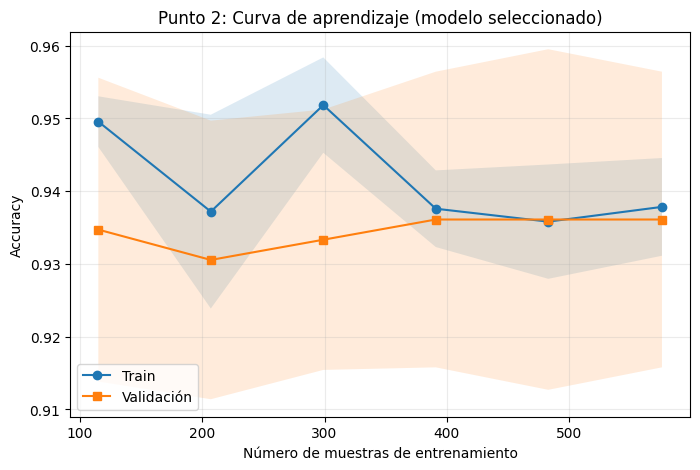

Resultado GridSearchCV
Mejores parámetros: {'C': 0.1, 'gamma': np.float64(0.5336699231206307)}
Mejor score CV: 0.9417
Score test (GridSearch): 0.9389
Score test (Punto 1): 0.9333


,modelo,gamma,C,score_test
0,Seleccionado punto 1,0.00100,1.0,0.933333
1,GridSearchCV,0.53367,0.1,0.938889


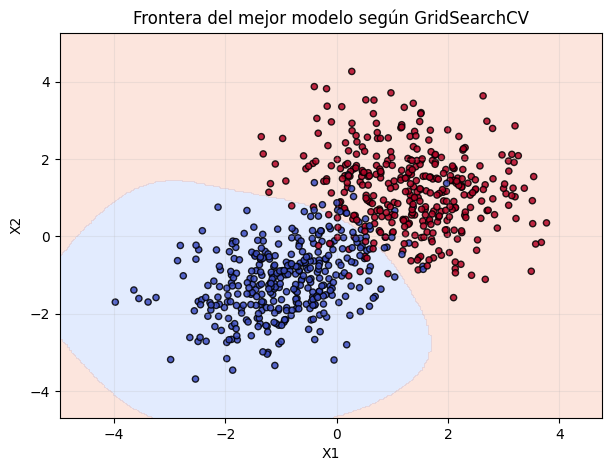

In [3]:
# Curva de aprendizaje del mejor modelo del punto 1
model_p2 = SVC(kernel="rbf", gamma=best_gamma, C=1.0, random_state=7)
plot_learning(model_p2, X_trainval, y_trainval, "Punto 2: Curva de aprendizaje (modelo seleccionado)")

# GridSearchCV para comparar con selección por curva gamma
param_grid = {
    "C": [0.1, 1, 10, 50],
    "gamma": np.logspace(-3, 2, 12),
}

grid = GridSearchCV(
    estimator=SVC(kernel="rbf", random_state=7),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid.fit(X_trainval, y_trainval)
best_grid = grid.best_estimator_
grid_test_score = accuracy_score(y_test, best_grid.predict(X_test))

print("Resultado GridSearchCV")
print("Mejores parámetros:", grid.best_params_)
print(f"Mejor score CV: {grid.best_score_:.4f}")
print(f"Score test (GridSearch): {grid_test_score:.4f}")
print(f"Score test (Punto 1): {test_score:.4f}")

# Tabla resumen
df_comp = pd.DataFrame(
    {
        "modelo": ["Seleccionado punto 1", "GridSearchCV"],
        "gamma": [best_gamma, grid.best_params_["gamma"]],
        "C": [1.0, grid.best_params_["C"]],
        "score_test": [test_score, grid_test_score],
    }
)
display(df_comp)

plot_decision_boundary(best_grid, X_trainval, y_trainval, "Frontera del mejor modelo según GridSearchCV")

### Punto 3: crear datasets para overfitting y underfitting

Tomamos el modelo base (SVC RBF) y construimos dos escenarios donde no será óptimo:

- **Escenario overfitting**: datos con ruido y pocos ejemplos; además usamos `gamma` alto y `C` alto para frontera muy compleja.
- **Escenario underfitting**: clases muy mezcladas y un modelo demasiado rígido (`gamma` y `C` bajos), que no captura bien la estructura.

Se reportan `accuracy` de train y test y se muestran fronteras para analizar visualmente.

Escenario Overfitting
Accuracy train: 1.0000
Accuracy test : 0.5306
Gap (train-test): 0.4694


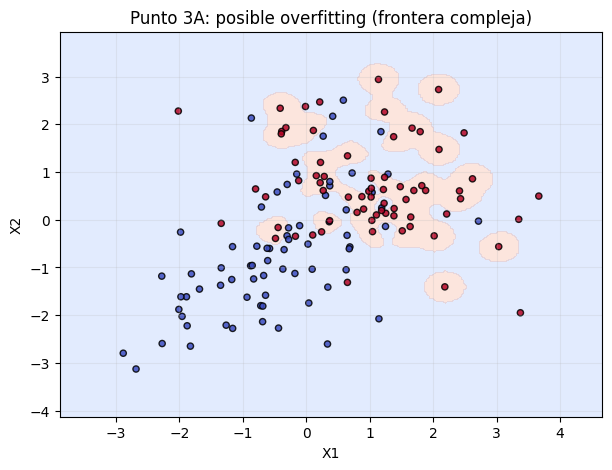


Escenario Underfitting
Accuracy train: 0.5659
Accuracy test : 0.6410
Gap (train-test): -0.0751


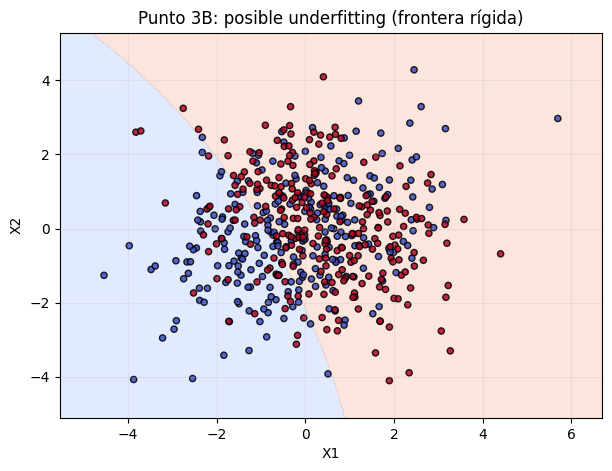

,escenario,accuracy_train,accuracy_test,gap_train_test
0,Overfitting,1.000000,0.530612,0.469388
1,Underfitting,0.565934,0.641026,-0.075092


Interpretación rápida:
- Overfitting suele mostrar train alto y caída marcada en test.
- Underfitting suele mostrar train y test relativamente bajos y frontera poco expresiva.


In [4]:
# -------------------------------
# Escenario A: Overfitting
# -------------------------------
X_over, y_over = make_gaussian_data(
    n0=70,
    n1=70,
    mu0=[-0.6, -0.8],
    mu1=[0.9, 0.8],
    cov0=[[1.3, 0.6], [0.6, 1.2]],
    cov1=[[1.4, -0.5], [-0.5, 1.1]],
    seed=17,
)

Xo_train, Xo_test, yo_train, yo_test = train_test_split(
    X_over,
    y_over,
    test_size=0.35,
    random_state=17,
    stratify=y_over,
)

# Modelo muy flexible (tiende a sobreajustar)
clf_over = SVC(kernel="rbf", gamma=20.0, C=120.0, random_state=17)
clf_over.fit(Xo_train, yo_train)

acc_over_train = accuracy_score(yo_train, clf_over.predict(Xo_train))
acc_over_test = accuracy_score(yo_test, clf_over.predict(Xo_test))

print("Escenario Overfitting")
print(f"Accuracy train: {acc_over_train:.4f}")
print(f"Accuracy test : {acc_over_test:.4f}")
print(f"Gap (train-test): {acc_over_train - acc_over_test:.4f}")

plot_decision_boundary(clf_over, X_over, y_over, "Punto 3A: posible overfitting (frontera compleja)")


# -------------------------------
# Escenario B: Underfitting
# -------------------------------
X_under, y_under = make_gaussian_data(
    n0=260,
    n1=260,
    mu0=[-0.2, -0.1],
    mu1=[0.3, 0.2],
    cov0=[[2.2, 0.7], [0.7, 2.0]],
    cov1=[[2.1, -0.6], [-0.6, 2.1]],
    seed=23,
)

Xu_train, Xu_test, yu_train, yu_test = train_test_split(
    X_under,
    y_under,
    test_size=0.30,
    random_state=23,
    stratify=y_under,
)

# Modelo muy rígido (tiende a subajustar)
clf_under = SVC(kernel="rbf", gamma=0.005, C=0.2, random_state=23)
clf_under.fit(Xu_train, yu_train)

acc_under_train = accuracy_score(yu_train, clf_under.predict(Xu_train))
acc_under_test = accuracy_score(yu_test, clf_under.predict(Xu_test))

print("\nEscenario Underfitting")
print(f"Accuracy train: {acc_under_train:.4f}")
print(f"Accuracy test : {acc_under_test:.4f}")
print(f"Gap (train-test): {acc_under_train - acc_under_test:.4f}")

plot_decision_boundary(clf_under, X_under, y_under, "Punto 3B: posible underfitting (frontera rígida)")

# Resumen final punto 3
df_p3 = pd.DataFrame(
    {
        "escenario": ["Overfitting", "Underfitting"],
        "accuracy_train": [acc_over_train, acc_under_train],
        "accuracy_test": [acc_over_test, acc_under_test],
        "gap_train_test": [acc_over_train - acc_over_test, acc_under_train - acc_under_test],
    }
)

display(df_p3)

print("Interpretación rápida:")
print("- Overfitting suele mostrar train alto y caída marcada en test.")
print("- Underfitting suele mostrar train y test relativamente bajos y frontera poco expresiva.")